In [ ]:
import duckdb
import pandas as pd
import logging

In [ ]:
logging.basicConfig(
    level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s',
    filename='pipeline.log'
)
logger = logging.getLogger(__name__)

## Data Preparation

In [ ]:
con = duckdb.connect('nyc_ems.duckdb')
con.execute("""
    --- create table of demoraphics from csv 
    CREATE TABLE IF NOT EXISTS demographics AS
    SELECT * FROM read_csv_auto('data/Demographics.csv');
    ALTER TABLE demographics ADD PRIMARY KEY (region_name);
""")
logger.info("Created demographics table")

con.execute("""
    --- create table of events, keeping only one record for event id 
    CREATE TABLE IF NOT EXISTS events AS
    SELECT * FROM ( 
        SELECT *,
           ROW_NUMBER() OVER (PARTITION BY event_id ORDER BY start_date_time ASC) AS rn
        FROM read_csv_auto('data/NYC_Events.csv')) sub
    WHERE rn = 1;
    ALTER TABLE events ADD PRIMARY KEY (event_id);
""")
logger.info("Created events table")

con.execute("""
    --- create table of weather data
    CREATE TABLE IF NOT EXISTS weather AS
    SELECT * FROM read_csv_auto('data/Weather.csv');
    ALTER TABLE weather ADD PRIMARY KEY (locationtimeID);
""")
logger.info("Created weather table")

con.execute("""
    --- create table of incidents from incident csv 
    CREATE TABLE IF NOT EXISTS incidents AS
    SELECT * FROM read_csv_auto('data/EMS_Incidents.csv');
    ALTER TABLE incidents ADD PRIMARY KEY (cad_incident_id);
""")
logger.info("Created incidents table")

con.execute("""
    --- create junction table linking events and incidents by locationtimeID 
    CREATE TABLE IF NOT EXISTS eventjunction AS
    SELECT e.event_id, e.locationtimeID, i.cad_incident_id
    FROM events e
    JOIN incidents i ON e.locationtimeID = i.locationtimeID;
    ALTER TABLE eventjunction ADD PRIMARY KEY (event_id, locationtimeID);
""")
logger.info("Created event junction table")
con.close()

## Query

In [ ]:
con = duckdb.connect('nyc_ems.duckdb') 

df = con.execute("""
    --- query to create table of daily incident counts by borough, 
        --- joined with weather, events, and demographics data
    SELECT 
        c.incident_datetime::DATE as date,
        c.borough,
        COUNT(c.cad_incident_id) as total_calls,
        AVG(w.temperature) as avg_temp,
        AVG(w.weathercode) as weathercode,
        COUNT(DISTINCT e.event_id) as num_events,
        AVG(crime_viol_rt) as violent_crime_rate,
        AVG(hh_inc_med_adj) as household_income,
        AVG(hh_u18_pct) as pct_under_18,
        AVG(pop_65p_pct) as pct_over_65,
        AVG(pop_num) as population
    FROM incidents c
    LEFT JOIN weather w ON c.locationtimeID = w.locationtimeID
    LEFT JOIN eventjunction ej
        ON c.cad_incident_id = ej.cad_incident_id
    LEFT JOIN events e
        ON ej.event_id = e.event_id
    LEFT JOIN demographics d ON c.borough = d.region_name
    GROUP BY c.incident_datetime::DATE, c.borough;
""").fetchdf()

con.close()

CatalogException: Catalog Error: Table with name incidents does not exist!
Did you mean "pg_indexes"?

LINE 14:     FROM incidents c
                  ^

## Solution Analysis

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

#drop target variable from X and save in y 
X = df.drop(columns=["total_calls", "date"])
y = df["total_calls"]

#one hot encoding for categorical variable, borough 
X = pd.get_dummies(X, columns=["borough"], drop_first=True)

#train test split for evaluation and training  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#create and train regressor 
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

#predict on testing data 
y_pred = model.predict(X_test)

#assessment metrics 
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
r2 = model.score(X_test, y_test)
print(f"R^2: {r2}")

Mean Squared Error: 4080.5649997800815
R^2: 0.9664328331174631


## Analysis Rationale      
When reading in the data from the tables, as I was using DuckDB I just read in the CSVs, as it infers the column name and types. I then created a primary key for each table which would later help with querying and eliminating duplicates. For the events table, I was repeatedly encountering issues with repeat rows with the same id, so I decided to select only one of them by choosing one with the earliest start. In order to combine the events and incidents table, I created a junction table which took in the eventID and incidentID from the events and incidents table, and then joined them on the locationtimeID. Since these would have a many to many relationship, at one given call time there can be many events occurring, and at the time of one event there can be many calls happening, a junction table would help with this. Since they would need to overlap on both time and location, I created a locationtimeID to just have one row overlapping. For the final query, I joined the weather on the locationtimeID, but did not need a junction table since this was not a many to many relationship. I created a dataframe that aggregated the total number of incidents for each day and borough. I then used this dataframe to train the predictive model.     
For this problem, I decided to solve it with a random forest. As I knew I wanted it to be predictive, I would have to do some algorithm that could return a prediction output based on data it was trained on. The output variable, the number of ems calls, was also numeric, so I knew I would need a model with a numeric output, not a category or binary output. I also considered creating a linear regression, however I did not think that the number of calls would have a direct linear relationship with the variables and there would instead be more complex relationships and interactions. I figured that a random forest could help with these nonlinear experiences and with the combination of categorical and numeric features that would be significant. Given that the end metrics of this were good, the R^2 was high, I decided that this was a good model for this task and sufficiently solved the problem. 

## Visualization 

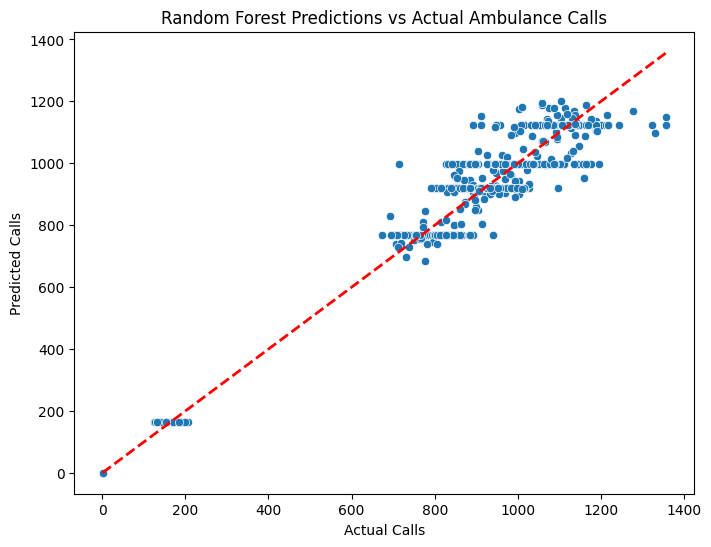

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)  # diagonal line for perfect prediction
plt.xlabel("Actual Calls")
plt.ylabel("Predicted Calls")
plt.title("Random Forest Predictions vs Actual Ambulance Calls")
plt.show()

## Visualization Rationale 